# Convolutional Neural Networks and Computer Vision Using TensorFlow


We're going to get specific and see how a special kind of neural network, [convolutional neural networks (CNNs)](https://en.wikipedia.org/wiki/Convolutional_neural_network) can be used for computer vision (detecting patterns in visual data).

In deep learning, many different kinds of model architectures can be used for different problems. For example, you could use a convolutional neural network for making predictions on image data and/or text data. However, in practice some architectures typically work better than others.

For example, you might want to:
* Classify whether a picture of food contains pizza 🍕 or steak 🥩 (we're going to do this)
* Detect whether or not an object appears in an image (e.g. did a specific car pass through a security camera?)


## What we're going to cover

Specifically, we're going to go through the follow with TensorFlow:

- Getting a dataset to work with
- Architecture of a convolutional neural network
- A quick end-to-end example (what we're working towards)
- Steps in modelling for binary image classification with CNNs
  - Becoming one with the data
  - Preparing data for modelling
  - Creating a CNN model (starting with a baseline)
  - Fitting a model (getting it to find patterns in our data)
  - Evaluating a model
  - Improving a model
  - Making a prediction with a trained model
- Steps in modelling for multi-class image classification with CNNs
 - Same as above (but this time with a different dataset).

## Get the data

The images we're going to work with are from the [Food-101 dataset](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/), a collection of 101 different categories of 101,000 (1000 images per category) real-world images of food dishes. 

To begin, we're only going to use two of the categories, pizza 🍕 and steak 🥩 and build a binary classifier.

We'll download the [pizza_steak](https://www.google.com/url?sa=E&source=gmail&q=https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip) subset .zip file and unzip it.

## Inspect the data

A very crucial step at the beginning of any machine learning project is becoming one with the data. This usually means plenty of visualizing and folder scanning to understand the data you're working with.

The file structure has been formatted to be in a typical format we might use for working with images.

More specifically:
* A `train` directory which contains all of the images in the training dataset with subdirectories each named after a certain class containing images of that class.
* A `test` directory with the same structure as the `train` directory.

```
Example of file structure

pizza_steak <- top level folder
└───train <- training images
│   └───pizza
│   │   │   1008104.jpg
│   │   │   1638227.jpg
│   │   │   ...      
│   └───steak
│       │   1000205.jpg
│       │   1647351.jpg
│       │   ...
│   
└───test <- testing images
│   └───pizza
│   │   │   1001116.jpg
│   │   │   1507019.jpg
│   │   │   ...      
│   └───steak
│       │   100274.jpg
│       │   1653815.jpg
│       │   ...    
 ```

In [1]:
import os

os.listdir('pizza_steak/')

['train', 'test']

In [2]:
# Walking through Pizza_Steak Directory and List Number of Files:

for dirpath, dirnames, filenames in os.walk('pizza_steak/'):
    print(f'There are {len(dirnames)} Directories and {len(filenames)} Images in {dirpath}')

There are 2 Directories and 0 Images in pizza_steak/
There are 2 Directories and 0 Images in pizza_steak/train
There are 0 Directories and 750 Images in pizza_steak/train/pizza
There are 0 Directories and 750 Images in pizza_steak/train/steak
There are 2 Directories and 0 Images in pizza_steak/test
There are 0 Directories and 250 Images in pizza_steak/test/pizza
There are 0 Directories and 250 Images in pizza_steak/test/steak


In [3]:
# Getting Names of Classes Programmatically:

import pathlib
import numpy as np

datadir = pathlib.Path('pizza_steak/train/')
class_names = np.array(sorted(item.name for item in datadir.glob('*')))

In [4]:
class_names

array(['pizza', 'steak'], dtype='<U5')

In [5]:
list(datadir.glob('*'))

[PosixPath('pizza_steak/train/pizza'), PosixPath('pizza_steak/train/steak')]

In [20]:
# Viewing an Image:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):

    # Setting Up Directory to View Image:
    target_folder = target_dir+target_class

    # Getting a Random Image Path:
    random_image = random.sample(os.listdir(target_folder), 1)

    # Reading in The Selected Image and Plotting it:
    img = plt.imread(target_folder+'/'+random_image[0])
    plt.imshow(img)
    plt.title(target_class)

    return img

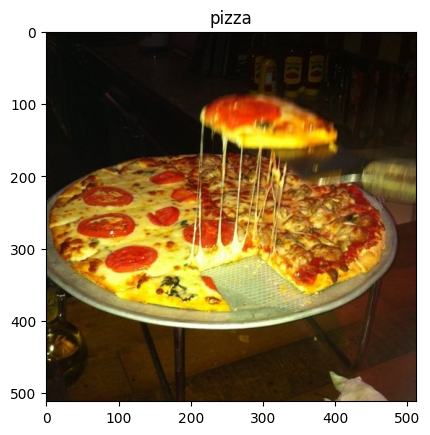

In [22]:
image = view_random_image(target_dir= 'pizza_steak/train/',
                         target_class= 'pizza')

In [23]:
image

array([[[11, 10,  5],
        [11, 10,  5],
        [11, 10,  5],
        ...,
        [17, 12,  6],
        [18, 14,  5],
        [18, 14,  5]],

       [[11, 10,  5],
        [11, 10,  5],
        [11, 10,  5],
        ...,
        [18, 13,  7],
        [18, 14,  5],
        [18, 14,  5]],

       [[12, 11,  6],
        [11, 10,  5],
        [11, 10,  5],
        ...,
        [18, 13,  7],
        [18, 14,  5],
        [18, 14,  5]],

       ...,

       [[29, 20, 13],
        [28, 19, 12],
        [28, 19, 12],
        ...,
        [65, 48, 32],
        [67, 49, 35],
        [67, 51, 36]],

       [[30, 21, 14],
        [29, 20, 13],
        [29, 20, 13],
        ...,
        [67, 51, 35],
        [67, 51, 36],
        [65, 52, 36]],

       [[30, 21, 14],
        [30, 21, 14],
        [29, 20, 13],
        ...,
        [72, 56, 40],
        [69, 56, 40],
        [68, 55, 39]]], dtype=uint8)

In [24]:
image.shape

(512, 512, 3)

Looking at the image shape more closely, you'll see it's in the form `(Width, Height, Colour Channels)`.

In our case, the width and height vary but because we're dealing with colour images, the colour channels value is always 3. This is for different values of [red, green and blue (RGB) pixels](https://en.wikipedia.org/wiki/RGB_color_model).

You'll notice all of the values in the `img` array are between 0 and 255. This is because that's the possible range for red, green and blue values.

For example, a pixel with a value `red=0, green=0, blue=255` will look very blue.

So when we build a model to differentiate between our images of `pizza` and `steak`, it will be finding patterns in these different pixel values which determine what each class looks like.

Many machine learning models, including neural networks prefer the values they work with to be between 0 and 1. Knowing this, one of the most common preprocessing steps for working with images is to **scale** (also referred to as **normalize**) their pixel values by dividing the image arrays by 255.

In [26]:
image.min(), image.max()

(0, 255)

In [27]:
# Getting all Pixel values Between 0 and 1:
image/255

array([[[0.04313725, 0.03921569, 0.01960784],
        [0.04313725, 0.03921569, 0.01960784],
        [0.04313725, 0.03921569, 0.01960784],
        ...,
        [0.06666667, 0.04705882, 0.02352941],
        [0.07058824, 0.05490196, 0.01960784],
        [0.07058824, 0.05490196, 0.01960784]],

       [[0.04313725, 0.03921569, 0.01960784],
        [0.04313725, 0.03921569, 0.01960784],
        [0.04313725, 0.03921569, 0.01960784],
        ...,
        [0.07058824, 0.05098039, 0.02745098],
        [0.07058824, 0.05490196, 0.01960784],
        [0.07058824, 0.05490196, 0.01960784]],

       [[0.04705882, 0.04313725, 0.02352941],
        [0.04313725, 0.03921569, 0.01960784],
        [0.04313725, 0.03921569, 0.01960784],
        ...,
        [0.07058824, 0.05098039, 0.02745098],
        [0.07058824, 0.05490196, 0.01960784],
        [0.07058824, 0.05490196, 0.01960784]],

       ...,

       [[0.11372549, 0.07843137, 0.05098039],
        [0.10980392, 0.0745098 , 0.04705882],
        [0.10980392, 0

## A (typical) architecture of a convolutional neural network

Components of a convolutional neural network:

| **Hyperparameter/Layer type** | **What does it do?** | **Typical values** |
| ----- | ----- | ----- |
| Input image(s) | Target images you'd like to discover patterns in| Whatever you can take a photo (or video) of |
| Input layer | Takes in target images and preprocesses them for further layers | `input_shape = [batch_size, image_height, image_width, color_channels]` |
| Convolution layer | Extracts/learns the most important features from target images | Multiple, can create with [`tf.keras.layers.ConvXD`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D) (X can be multiple values) |
| Hidden activation | Adds non-linearity to learned features (non-straight lines) | Usually ReLU ([`tf.keras.activations.relu`](https://www.tensorflow.org/api_docs/python/tf/keras/activations/relu)) |
| Pooling layer | Reduces the dimensionality of learned image features | Average ([`tf.keras.layers.AvgPool2D`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/AveragePooling2D)) or Max ([`tf.keras.layers.MaxPool2D`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D)) |
| Fully connected layer | Further refines learned features from convolution layers | [`tf.keras.layers.Dense`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) |
| Output layer | Takes learned features and outputs them in shape of target labels | `output_shape = [number_of_classes]` (e.g. 3 for pizza, steak or sushi)|
| Output activation | Adds non-linearities to output layer | [`tf.keras.activations.sigmoid`](https://www.tensorflow.org/api_docs/python/tf/keras/activations/sigmoid) (binary classification) or [`tf.keras.activations.softmax`](https://www.tensorflow.org/api_docs/python/tf/keras/activations/softmax) |

How they stack together:

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-simple-convnet.png)

**Great Resource to Understand CNN**

https://poloclub.github.io/cnn-explainer/

# An End-to-End Example:

In [28]:
# Importing Necessary Libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

In [29]:
# Building Convolutional Neural Network:

tf.random.set_seed(42)

# Pre-Processing Data (Getting all pixel values between 0 and 1):
train_datagen = ImageDataGenerator(rescale= 1/255.0)
valid_datagen = ImageDataGenerator(rescale= 1/255.0)

# Setting up Path to Directories:
train_dir = 'pizza_steak/train'
test_dir = 'pizza_steak/test'

# Importing Images from Directories and Turn it into Batches:
train_data = train_datagen.flow_from_directory(directory= train_dir,
                                              target_size= (224,224),
                                              batch_size= 32,
                                              class_mode= 'binary',
                                              seed= 42)

valid_data = valid_datagen.flow_from_directory(directory= test_dir,
                                              target_size= (224,224),
                                              batch_size= 32,
                                              class_mode= 'binary',
                                              seed= 42)


# Creating a CNN Model:
model_1 = Sequential()

model_1.add(InputLayer(shape= (224, 224, 3)))

model_1.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))

model_1.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))

model_1.add(MaxPool2D(pool_size= 2,
                     padding= 'valid'))

model_1.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))

model_1.add(Conv2D(filters= 10,
                  kernel_size= 3,
                  activation= 'relu'))

model_1.add(MaxPool2D(pool_size= 2))

model_1.add(Flatten())

model_1.add(Dense(units= 1, activation= 'sigmoid'))

model_1.compile(optimizer= tf.keras.optimizers.Adam(),
               loss= tf.keras.losses.BinaryCrossentropy(),
               metrics= ['accuracy'])

history_1 = model_1.fit(train_data,
                       epochs= 5,
                       validation_data= valid_data)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


I0000 00:00:1767886152.575963    2947 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/5


2026-01-08 15:29:16.081943: I external/local_xla/xla/service/service.cc:163] XLA service 0x763468004500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-08 15:29:16.081991: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-01-08 15:29:16.167427: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-08 15:29:16.487497: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


 3/47 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.4948 - loss: 0.7013

I0000 00:00:1767886160.798621    4405 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step - accuracy: 0.6833 - loss: 0.5889 - val_accuracy: 0.7760 - val_loss: 0.4688
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.7807 - loss: 0.4782 - val_accuracy: 0.8180 - val_loss: 0.4193
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.8000 - loss: 0.4490 - val_accuracy: 0.8520 - val_loss: 0.3856
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.8187 - loss: 0.4100 - val_accuracy: 0.8400 - val_loss: 0.3683
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.8527 - loss: 0.3422 - val_accuracy: 0.8000 - val_loss: 0.4137


In [30]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

#### Using the same model as before

To examplify how neural networks can be adapted to many different problems, let's see how a binary classification model we've previously built might work with our data.

We can use all of the same parameters in our previous model except for changing two things:
* **The data** - we're now working with images instead of dots.
* **The input shape** - we have to tell our neural network the shape of the images we're working with.
  * A common practice is to reshape images all to one size. In our case, we'll resize the images to `(224, 224, 3)`, meaning a height and width of 224 pixels and a depth of 3 for the red, green, blue colour channels.

In [32]:
tf.random.set_seed(42)

model_2 = Sequential()

model_2.add(InputLayer(shape= (224, 224, 3)))
model_2.add(Flatten())

model_2.add(Dense(units= 4, activation= 'relu'))
model_2.add(Dense(units= 4, activation= 'relu'))
model_2.add(Dense(units= 1, activation= 'sigmoid'))

model_2.compile(optimizer= tf.keras.optimizers.Adam(),
               loss= tf.keras.losses.BinaryCrossentropy(),
               metrics= ['accuracy'])

history_2 = model_2.fit(train_data,
                       epochs= 5,
                       validation_data= valid_data)

Epoch 1/5


2026-01-08 15:36:24.848218: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_120', 4 bytes spill stores, 4 bytes spill loads

2026-01-08 15:36:24.871767: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_120', 4 bytes spill stores, 4 bytes spill loads



14/47 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.5497 - loss: 8.5439

2026-01-08 15:36:25.497066: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_120', 4 bytes spill stores, 4 bytes spill loads



47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6090 - loss: 6.3271

2026-01-08 15:36:31.418922: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_20', 4 bytes spill stores, 4 bytes spill loads



47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.6727 - loss: 3.8699 - val_accuracy: 0.6320 - val_loss: 1.4078
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.6880 - loss: 1.9312 - val_accuracy: 0.7040 - val_loss: 0.8804
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7360 - loss: 0.9615 - val_accuracy: 0.7680 - val_loss: 0.7023
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.7653 - loss: 0.7148 - val_accuracy: 0.7640 - val_loss: 0.6371
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8093 - loss: 0.4958 - val_accuracy: 0.7780 - val_loss: 0.5797


In [34]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

One of the most noticeable things here is the much larger number of parameters in `model_2` versus `model_1`.

`model_2` has 602,141 trainable parameters where as `model_1` has only 31,101. And despite this difference, `model_1` still far and large out performs `model_2`.

You can think of trainable parameters as *patterns a model can learn from data*. Intuitiely, you might think more is better. And in some cases it is. But in this case, the difference here is in the two different styles of model we're using. Where a series of dense layers have a number of different learnable parameters connected to each other and hence a higher number of possible learnable patterns, **a convolutional neural network seeks to sort out and learn the most important patterns in an image**. So even though there are less learnable parameters in our convolutional neural network, these are often more helpful in deciphering between different **features** in an image.

Since our previous model didn't work we will increase the number of layers and even increase the number of neurons in each layer.

More specifically, we'll increase the number of neurons (also called hidden units) in each dense layer from 4 to 100 and add an extra layer.

Adding extra layers or increasing the number of neurons in each layer is often referred to as increasing the **complexity** of your model.

In [36]:
tf.random.set_seed(42)

model_3 = Sequential()

model_3.add(InputLayer(shape= (224,224,3)))
model_3.add(Flatten())
model_3.add(Dense(units= 100, activation= 'relu'))
model_3.add(Dense(units= 100, activation= 'relu'))
model_3.add(Dense(units= 100, activation= 'relu'))
model_3.add(Dense(units= 1, activation= 'sigmoid'))

model_3.compile(optimizer= tf.keras.optimizers.Adam(),
               loss= tf.keras.losses.BinaryCrossentropy(),
               metrics= ['accuracy'])

model_3.fit(train_data,
           epochs= 5,
           validation_data= valid_data)

Epoch 1/5


2026-01-08 15:48:12.167244: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-08 15:48:12.167351: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-08 15:48:12.167417: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-08 15:48:12.167429: I external/l

14/47 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.5122 - loss: 6.4174

2026-01-08 15:48:17.320394: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-08 15:48:17.320466: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-08 15:48:18.314652: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_161', 20 bytes spill stores, 20 bytes spill loads



47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5687 - loss: 4.7410

2026-01-08 15:48:23.764684: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-08 15:48:24.543589: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_29', 20 bytes spill stores, 20 bytes spill loads



47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 202ms/step - accuracy: 0.6300 - loss: 2.7800 - val_accuracy: 0.5040 - val_loss: 1.8466
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6760 - loss: 0.9729 - val_accuracy: 0.7500 - val_loss: 0.5935
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.7493 - loss: 0.5386 - val_accuracy: 0.7940 - val_loss: 0.4310
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.7687 - loss: 0.5118 - val_accuracy: 0.6760 - val_loss: 0.6299
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7300 - loss: 0.6708 - val_accuracy: 0.7580 - val_loss: 0.5255


In [37]:
model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

The number of trainable parameters has increased even more than `model_2`. And even with close to 500x (~15,000,000 vs. ~31,000) more trainable parameters, `model_3` still doesn't out perform `model_1`.

This goes to show the power of convolutional neural networks and their ability to learn patterns despite using less parameters.